# Diabetes Risk Prediction

#### Predicting whether a patient is diabetic based on medical measurements.
 Dataset from UCI Machine Learning Repository — 768 patients, 8 features.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/diabetes.csv')
print(df.shape)
df.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Column Descriptions

- Pregnancies: number of times pregnant
- Glucose: plasma glucose concentration
- BloodPressure: diastolic blood pressure (mm Hg)
- SkinThickness: triceps skinfold thickness (mm)
- Insulin: serum insulin level
- BMI: body mass index
- DiabetesPedigreeFunction: genetic risk based on family history
- Age: age in years
- Outcome: 1 = diabetic, 0 = not diabetic

In [4]:
# check data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


## Checking for Missing Values

Some columns have 0 values that are medically impossible (like BMI = 0 or Glucose = 0).
These are actually missing values stored as zeros.

In [5]:
# these columns cannot have 0 in real life
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols_with_zeros:
    zero_count = (df[col] == 0).sum()
    print(f"{col}: {zero_count} zeros ({round(zero_count/len(df)*100, 1)}%)")

Glucose: 5 zeros (0.7%)
BloodPressure: 35 zeros (4.6%)
SkinThickness: 227 zeros (29.6%)
Insulin: 374 zeros (48.7%)
BMI: 11 zeros (1.4%)


## Target Variable Distribution

Checking how many patients are diabetic vs non-diabetic.

Outcome
0    500
1    268
Name: count, dtype: int64

Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64


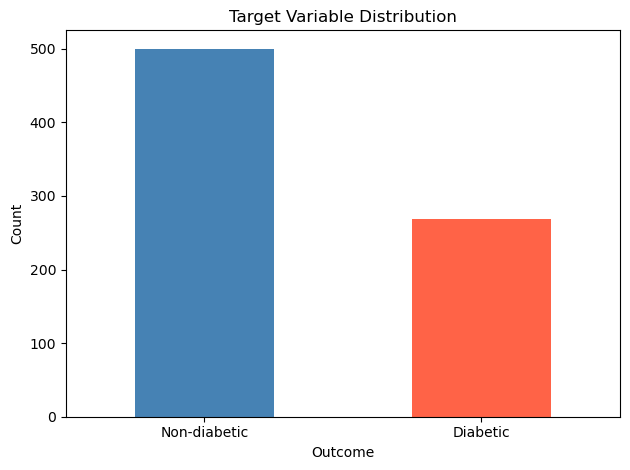

In [6]:
print(df['Outcome'].value_counts())
print()
print(df['Outcome'].value_counts(normalize=True).round(3))

df['Outcome'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.xticks([0, 1], ['Non-diabetic', 'Diabetic'], rotation=0)
plt.title('Target Variable Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../outputs/figures/01_target_distribution.png', dpi=150)
plt.show()

## Basic Statistics

Looking at the range of values for each feature.

In [8]:
df.describe().round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00
